In [2]:
import requests
import regex as re
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## "Analyzing Kerala Tour Package Pricing and Trends Using Web-Scraped Data"
Online travel aggregators like TravelTriangle list thousands of Kerala tour packages with varying durations, destinations, ratings, and prices, but this information is scattered across hundreds of web pages with no easy way to compare options. The goal of this project is to scrape, clean, and analyze Kerala tour package data to uncover pricing patterns, identify the most visited destinations, compare package types, detect pricing outliers, and surface the best-value packages — turning unstructured web data into actionable travel and business insights.

## Objectives

1. Collect data by web-scraping Kerala tour package listings (name, duration, type, ratings, discount, prices, destinations) from TravelTriangle.
2. Clean and preprocess the raw data — handle missing values and convert text fields into proper numeric formats.
3. Engineer new features such as Days/Nights, Price-per-Day, and 1D/2D/3D city splits for deeper analysis.
4. Analyze distributions of price, duration, ratings, and discounts (univariate analysis).
5. Identify top destinations and their impact on average package pricing.
6. Study relationships between price, duration, discount, and rating using correlation and scatter analysis.
7. Compare package types on average price, discount, and rating.
8. Detect pricing outliers using the IQR method to flag (not discard) premium/luxury packages.
9. Generate ranked insights — cheapest, most expensive, and best value-for-money packages.
10. Derive actionable insights to help travelers choose better and help businesses understand market positioning.

In [3]:
package_name=[]
duration=[]
package_type=[]
ratings=[]
discount=[]
new_prices= []
old_prices= []
cities=[]

In [ ]:
for i in range(1,62):
    url=f'https://traveltriangle.com/tour-packages/Kerala/page/{i}'
    #print(url)

    response=requests.get(url)
    #print('Page:',i,response.status_code)

    html_data=response.text
    soup=BeautifulSoup(html_data)

    # package name
    name=soup.find_all('span',class_='fw9 m0 f16 pfc3')
    for i in name:
        package_name.append(i.text)


    # Duration
    dur=soup.find_all('span',class_='iblock sfc6')
    for i in dur:
        duration.append(i.text)


    # Package Type
    type=soup.find_all('span',class_='pfc4 iblock')
    for i in type:
        package_type.append(i.text)


    # Ratings
    rat=soup.find_all('label',class_='pr0 pt0 pl20')
    for i in rat:
        ratings.append(i.text)


    # Discount
    dis=soup.find_all('span',class_='f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label')
    for i in dis:
        discount.append(i.text)


    # Prices
    for p in soup.find_all('p', class_='priceVal'):

    # New Price
        new_price = re.sub(r'[^0-9]', '', p.contents[0])
        new_prices.append(int(new_price))

    # Old Price
        old_tag = p.find('span', class_='at_oldprice')

        if old_tag:
            old_price = re.sub(r'[^0-9]', '', old_tag.text)
            old_prices.append(int(old_price))
        else:
            old_prices.append(None)


    # Cities
    city=soup.find_all('ul',class_='clearfix package-cities-list at_packagecity_list')
    for i in city:
        cities.append(i.text)


In [ ]:
print(package_name)
print('*'*1000)
print(duration)
print('*'*1000)
print(package_type)
print('*'*1000)
print(ratings)
print('*'*1000)
print(discount)
print('*'*1000)
print(new_prices)
print('*'*1000)
print(old_prices)
print('*'*1000)
print(cities)

['Alleppey-Munnar Kerala Weekend Tour ', 'Charismatic Kochi Tour Package', 'Hills & Houseboat: Munnar and Alleppey Honeymoon Package ', 'Vibrant Kochi Munnar Honeymoon Tour Package', 'Mesmerizing Getaway To Kochi', 'Kerala Wayanad Weekend Holiday', 'Trip To Mesmerising Munnar ', 'Best Selling Kerala Honeymoon Tour Package', 'Catch The Beauty Of The Setting Sun In Alleppey', 'Best Selling Kerala Houseboat & Jungle Safari Tour Package', 'Charming Alleppey Honeymoon Package', 'A Blissful Tour In Munnar', 'Top 5 Nights 6 Days Kerala Family Tour Packages For A Refreshing Getaway', 'Exploring Godâ\x80\x99s Own Country, Kerala', 'Reasonable Munnar Thekkady Alleppey Honeymoon Packages', 'Ecstatic Athirapally Tour Package', 'Mesmerizing Kerala Holiday: Weekend in Munnar & Thekkady', 'Captivating Thekkady Honeymoon Package', 'A Surreal Escape To Mesmerising Destinations', 'Visit Kerala And See Astounding Places', 'Exclusive Kerala Munnar Tour Packages for an Amazing Vacation', 'Exciting Athirapa

In [ ]:
print(len(package_name))
print(len(duration))
print(len(package_type))
print(len(ratings))
print(len(discount))
print(len(new_prices))
print(len(old_prices))
print(len(cities))

2300
2300
2300
2300
2300
2300
2300
2300


In [ ]:
package_name=package_name[:2300]
duration=duration[:2300]
package_type=package_type[:2300]
ratings=ratings[:2300]
discount=discount[:2300]
new_prices=new_prices[:2300]
old_prices=old_prices[:2300]
cities=cities[:2300]

In [ ]:
df=pd.DataFrame({'Package Name':package_name,
                'Package Type':package_type,
                'Duration':duration,
                'Ratings':ratings,
                'Discount':discount,
                'New Prices':new_prices,
                'Old Prices':old_prices,
                'Cities':cities})

In [ ]:
df

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,Cities
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24% Off,13020,17132.0,Munnar (2D)Alleppey (2D)
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9% Off,15000,16484.0,Kochi (1D)Munnar (3D)
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10% Off,22000,24444.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (2D)
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10% Off,14571,16190.0,Cochin (1D)Munnar (3D)
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9% Off,4800,5275.0,Kochi (2D)
...,...,...,...,...,...,...,...,...
2295,"5-Day Kerala Adventure: Munnar, Kumarakom & Ko...",Customizable,5 Days & 4 Nights,3 Star,8% Off,31850,35000.0,Munnar (2D)Alleppey (1D)Kovalam (1D)Trivandrum...
2296,Kerala Tour with Alleppey's Houseboat Stay,Customizable,6 Days & 5 Nights,3 Star,15% Off,14738,16375.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kovalam (...
2297,3-Day Kerala Tour from Kochi to Munnar,Customizable,3 Days & 2 Nights,3 Star,13% Off,11500,12500.0,Munnar (2D)Cochin (1D)
2298,Book A Memorable Trip To Malappuram,Customizable,2 Days & 1 Nights,3 Star,9% Off,8000,8791.0,Malappuram (1D)Calicut (1D)


In [ ]:
def split_cities(city_string):

    matches = re.findall(r'([^→]+?)\s*\((\d+)D\)', city_string)

    one_day = []
    two_day = []
    three_day = []

    for city, day in matches:
        city = city.strip()

        if day == '1':
            one_day.append(city)
        elif day == '2':
            two_day.append(city)
        elif day == '3':
            three_day.append(city)

    return pd.Series([
        ', '.join(one_day),
        ', '.join(two_day),
        ', '.join(three_day)
    ])

df[['1D Cities', '2D Cities', '3D Cities']] = df['Cities'].apply(split_cities)

In [ ]:
df.shape

(2300, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Package Name  2300 non-null   object 
 1   Package Type  2300 non-null   object 
 2   Duration      2300 non-null   object 
 3   Ratings       2300 non-null   object 
 4   Discount      2300 non-null   object 
 5   New Prices    2300 non-null   int64  
 6   Old Prices    2297 non-null   float64
 7   Cities        2300 non-null   object 
 8   1D Cities     2300 non-null   object 
 9   2D Cities     2300 non-null   object 
 10  3D Cities     2300 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 197.8+ KB


In [ ]:
df.drop(columns='Cities')

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,1D Cities,2D Cities,3D Cities
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24% Off,13020,17132.0,,"Munnar, Alleppey",
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9% Off,15000,16484.0,Kochi,,Munnar
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10% Off,22000,24444.0,"Thekkady, Alleppey","Munnar, Kochi",
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10% Off,14571,16190.0,Cochin,,Munnar
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9% Off,4800,5275.0,,Kochi,
...,...,...,...,...,...,...,...,...,...,...
2295,"5-Day Kerala Adventure: Munnar, Kumarakom & Ko...",Customizable,5 Days & 4 Nights,3 Star,8% Off,31850,35000.0,"Alleppey, Kovalam, Trivandrum",Munnar,
2296,Kerala Tour with Alleppey's Houseboat Stay,Customizable,6 Days & 5 Nights,3 Star,15% Off,14738,16375.0,"Thekkady, Alleppey, Kovalam, Trivandrum",Munnar,
2297,3-Day Kerala Tour from Kochi to Munnar,Customizable,3 Days & 2 Nights,3 Star,13% Off,11500,12500.0,Cochin,Munnar,
2298,Book A Memorable Trip To Malappuram,Customizable,2 Days & 1 Nights,3 Star,9% Off,8000,8791.0,"Malappuram, Calicut",,


In [ ]:
df.isnull().sum()

Package Name    0
Package Type    0
Duration        0
Ratings         0
Discount        0
New Prices      0
Old Prices      3
Cities          0
1D Cities       0
2D Cities       0
3D Cities       0
dtype: int64

In [ ]:
df['Old Prices']=df['Old Prices'].fillna(df['Old Prices'].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Package Name  2300 non-null   object 
 1   Package Type  2300 non-null   object 
 2   Duration      2300 non-null   object 
 3   Ratings       2300 non-null   object 
 4   Discount      2300 non-null   object 
 5   New Prices    2300 non-null   int64  
 6   Old Prices    2300 non-null   float64
 7   Cities        2300 non-null   object 
 8   1D Cities     2300 non-null   object 
 9   2D Cities     2300 non-null   object 
 10  3D Cities     2300 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 197.8+ KB


# **Univariate Data Visualization**

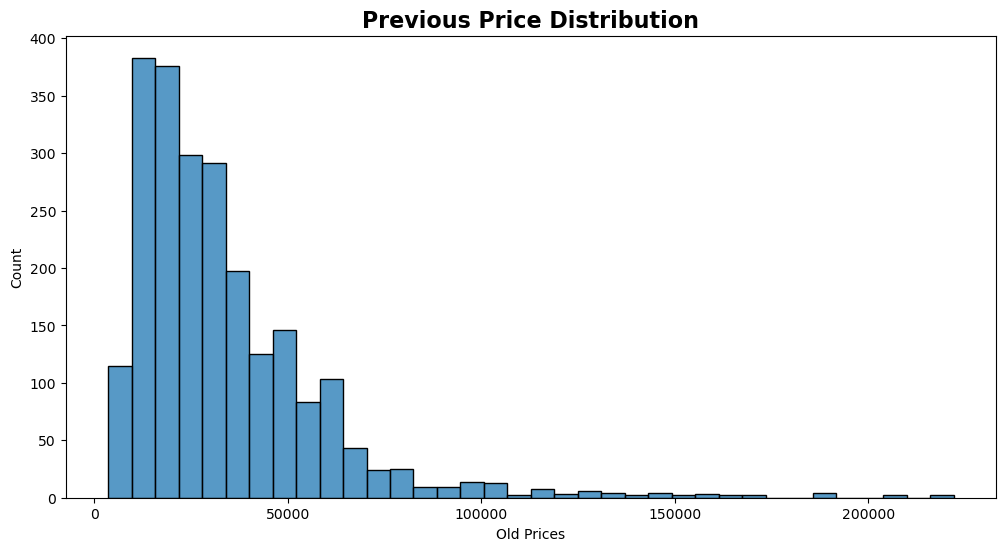

In [ ]:
# Price Visualization
plt.figure(figsize=(12,6))
sns.histplot(df,x='Old Prices',bins=36)
plt.title('Previous Price Distribution',fontsize=16, fontweight='bold')
plt.show()

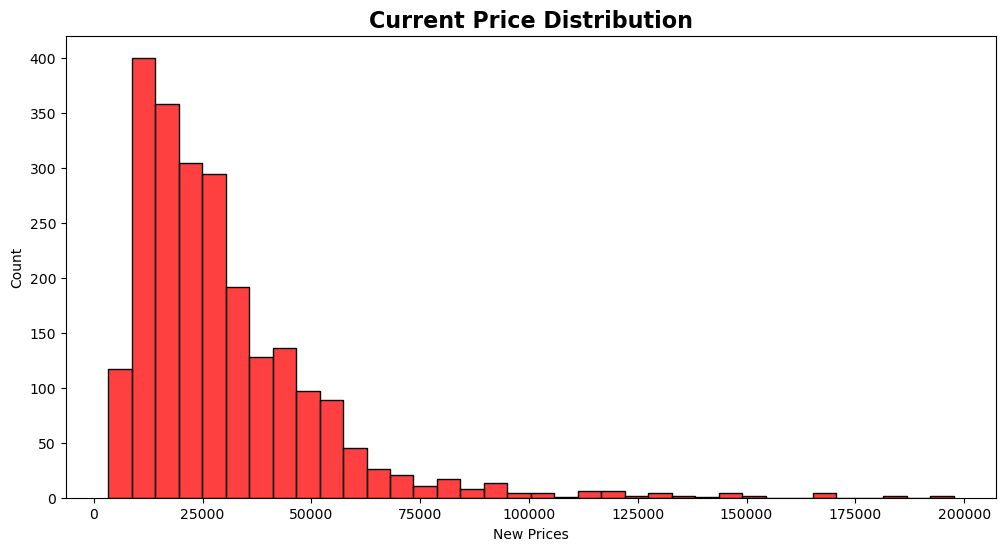

In [ ]:
# Price Visualization
plt.figure(figsize=(12,6))
sns.histplot(df,x='New Prices',bins=36,color='red')
plt.title('Current Price Distribution',fontsize=16, fontweight='bold')
plt.show()

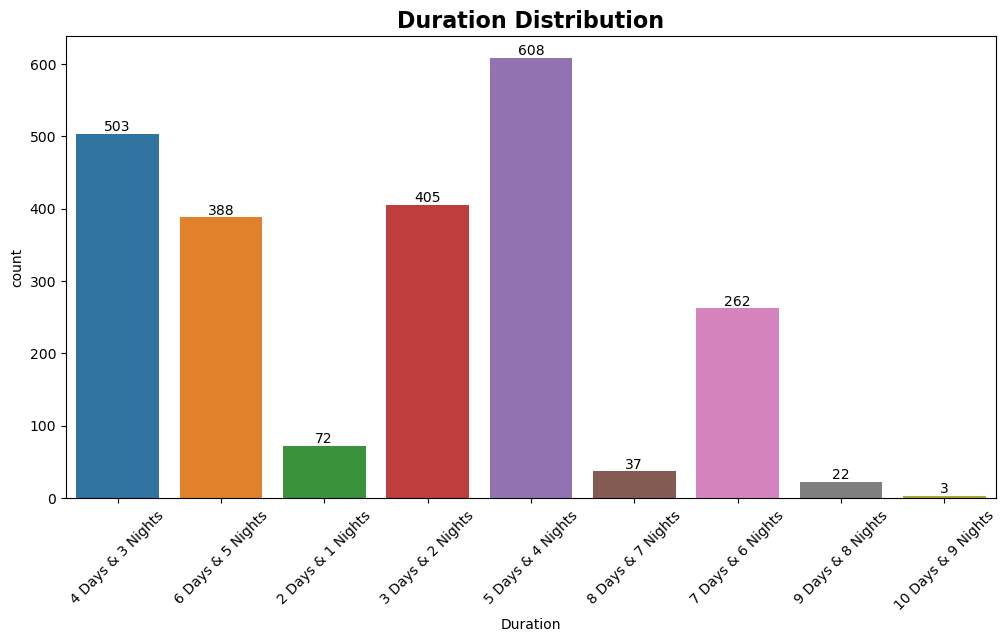

In [ ]:
# Duration Visualization
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, x='Duration', palette='tab10')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Duration Distribution',fontsize=16, fontweight='bold')
plt.show()

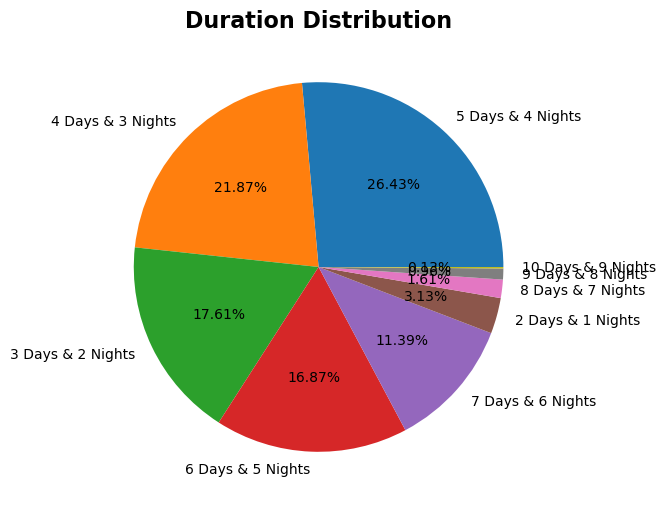

In [ ]:
# Duration Visualization
plt.figure(figsize=(12,6))
dur_counts=df['Duration'].value_counts()
plt.pie(dur_counts.values,
        labels=dur_counts.index,
        autopct='%0.2f%%')
plt.title('Duration Distribution',fontsize=16, fontweight='bold')
plt.show()

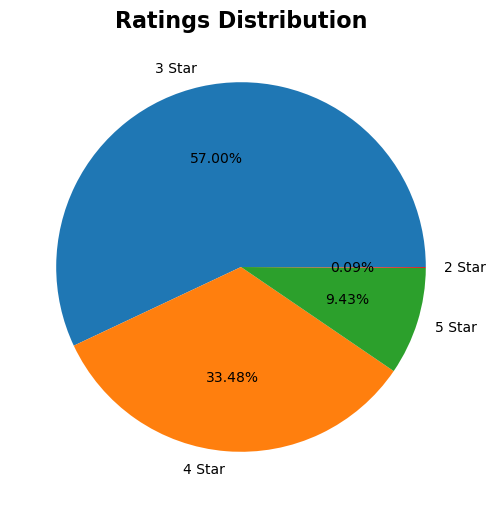

In [ ]:
# Ratings
plt.figure(figsize=(12,6))
dur_counts=df['Ratings'].value_counts()
plt.pie(dur_counts.values,
        labels=dur_counts.index,
        autopct='%0.2f%%')
plt.title('Ratings Distribution',fontsize=16, fontweight='bold')
plt.show()

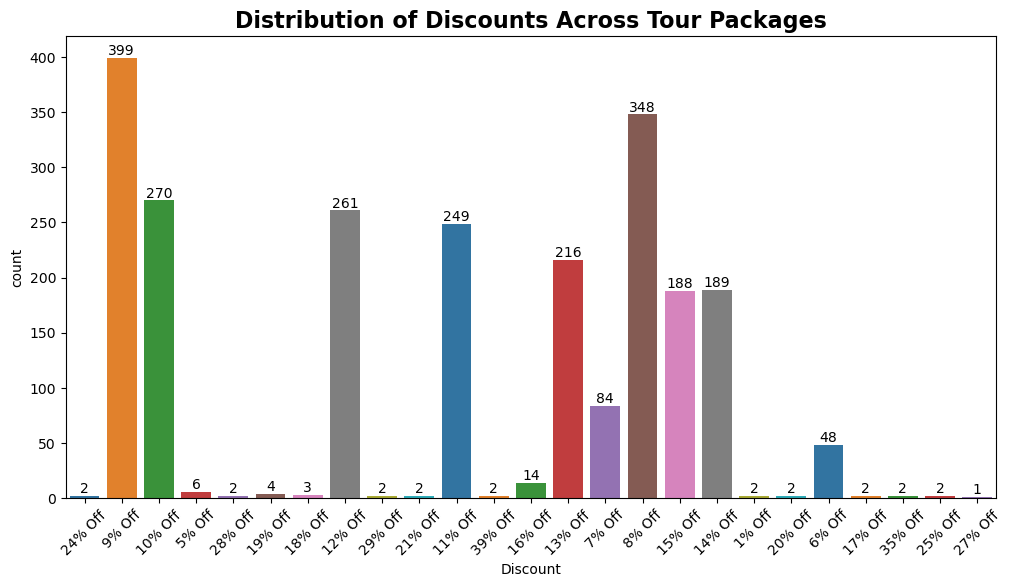

In [ ]:
# Discounts
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, x='Discount', palette='tab10')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Distribution of Discounts Across Tour Packages',
          fontsize=16, fontweight='bold')
plt.show()

# **Further Analysis**

Going beyond distribution plots: cleaning numeric fields properly, destination-level insights, price relationships, package-type comparisons, outlier checks, and a top/bottom packages table.

# **1. Clean Duration, Discount, and Ratings into proper numeric columns**

These are currently strings (e.g. `'5D/4N'`, `'20%'`), so they can't be used in correlations, groupby aggregations, or scatterplots until converted.

In [ ]:
# Extract numeric Days and Nights from Duration (e.g. '4 Days & 3 Nights' -> 4, 3)
df['Days'] = df['Duration'].str.extract(r'(\d+)\s*Days?').astype(int)
df['Nights'] = df['Duration'].str.extract(r'(\d+)\s*Nights?').astype(int)

# Discount is already like '24%'
df['Discount_num'] = df['Discount'].str.extract(r'(\d+)').astype(float)

# Ratings is like '3 Star' -> pull out the digit instead of converting the whole string
df['Ratings_num'] = df['Ratings'].str.extract(r'(\d+)').astype(int)


In [ ]:
df

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,Cities,1D Cities,2D Cities,3D Cities,Days,Nights,Discount_num,Ratings_num
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24% Off,13020,17132.0,Munnar (2D)Alleppey (2D),,"Munnar, Alleppey",,4,3,24.0,3
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9% Off,15000,16484.0,Kochi (1D)Munnar (3D),Kochi,,Munnar,4,3,9.0,4
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10% Off,22000,24444.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (2D),"Thekkady, Alleppey","Munnar, Kochi",,6,5,10.0,5
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10% Off,14571,16190.0,Cochin (1D)Munnar (3D),Cochin,,Munnar,4,3,10.0,3
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9% Off,4800,5275.0,Kochi (2D),,Kochi,,2,1,9.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,"5-Day Kerala Adventure: Munnar, Kumarakom & Ko...",Customizable,5 Days & 4 Nights,3 Star,8% Off,31850,35000.0,Munnar (2D)Alleppey (1D)Kovalam (1D)Trivandrum...,"Alleppey, Kovalam, Trivandrum",Munnar,,5,4,8.0,3
2296,Kerala Tour with Alleppey's Houseboat Stay,Customizable,6 Days & 5 Nights,3 Star,15% Off,14738,16375.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kovalam (...,"Thekkady, Alleppey, Kovalam, Trivandrum",Munnar,,6,5,15.0,3
2297,3-Day Kerala Tour from Kochi to Munnar,Customizable,3 Days & 2 Nights,3 Star,13% Off,11500,12500.0,Munnar (2D)Cochin (1D),Cochin,Munnar,,3,2,13.0,3
2298,Book A Memorable Trip To Malappuram,Customizable,2 Days & 1 Nights,3 Star,9% Off,8000,8791.0,Malappuram (1D)Calicut (1D),"Malappuram, Calicut",,,2,1,9.0,3


In [ ]:
df.drop(columns='Cities')

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,1D Cities,2D Cities,3D Cities,Days,Nights,Discount_num,Ratings_num
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24% Off,13020,17132.0,,"Munnar, Alleppey",,4,3,24.0,3
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9% Off,15000,16484.0,Kochi,,Munnar,4,3,9.0,4
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10% Off,22000,24444.0,"Thekkady, Alleppey","Munnar, Kochi",,6,5,10.0,5
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10% Off,14571,16190.0,Cochin,,Munnar,4,3,10.0,3
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9% Off,4800,5275.0,,Kochi,,2,1,9.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,"5-Day Kerala Adventure: Munnar, Kumarakom & Ko...",Customizable,5 Days & 4 Nights,3 Star,8% Off,31850,35000.0,"Alleppey, Kovalam, Trivandrum",Munnar,,5,4,8.0,3
2296,Kerala Tour with Alleppey's Houseboat Stay,Customizable,6 Days & 5 Nights,3 Star,15% Off,14738,16375.0,"Thekkady, Alleppey, Kovalam, Trivandrum",Munnar,,6,5,15.0,3
2297,3-Day Kerala Tour from Kochi to Munnar,Customizable,3 Days & 2 Nights,3 Star,13% Off,11500,12500.0,Cochin,Munnar,,3,2,13.0,3
2298,Book A Memorable Trip To Malappuram,Customizable,2 Days & 1 Nights,3 Star,9% Off,8000,8791.0,"Malappuram, Calicut",,,2,1,9.0,3


In [ ]:
df.to_csv('kerala_tour_packages.csv', index=False)

In [ ]:
df.describe()

,New Prices,Old Prices,Days,Nights,Discount_num,Ratings_num
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,30007.450435,33803.834131,4.824783,3.824783,10.863043,3.522609
std,22374.112465,25335.431552,1.459380,1.459380,2.939721,0.663412
min,3324.000000,3613.000000,2.000000,1.000000,1.000000,2.000000
25%,14880.000000,16900.000000,4.000000,3.000000,9.000000,3.000000
50%,24239.500000,27400.000000,5.000000,4.000000,10.000000,3.000000
75%,37856.000000,42850.000000,6.000000,5.000000,13.000000,4.000000
max,197580.000000,222000.000000,10.000000,9.000000,39.000000,5.000000


# **2. Destination-level analysis**

Which Kerala destinations appear most often across all packages, and which are associated with higher prices?

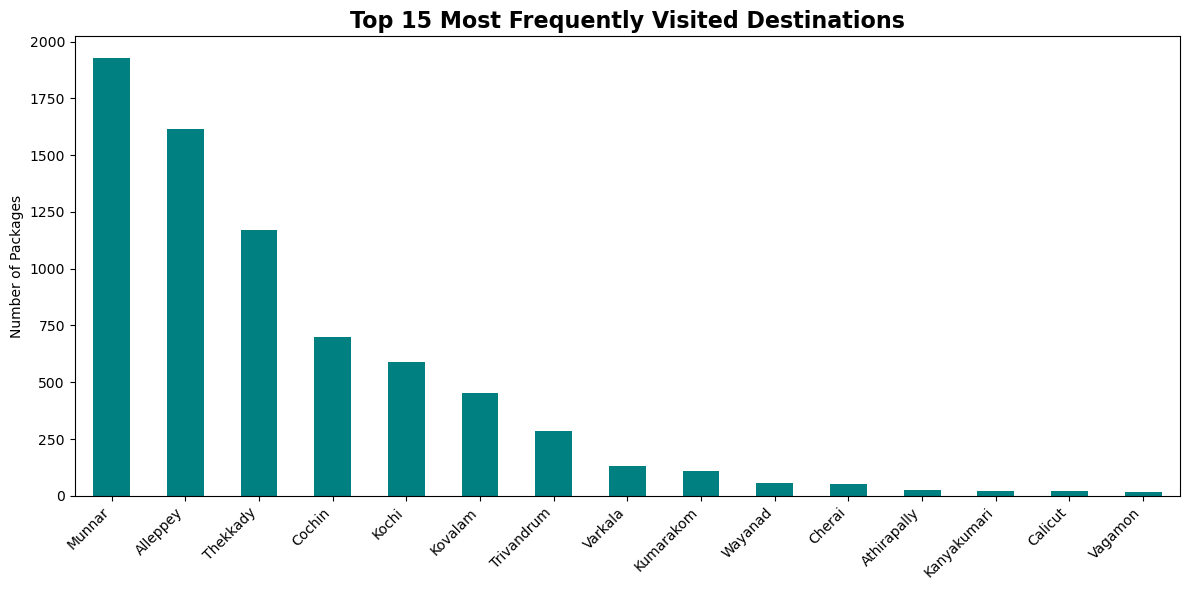

In [ ]:
# Combine all city columns into one list of individual destinations
all_cities = pd.concat([
    df['1D Cities'].str.split(', '),
    df['2D Cities'].str.split(', '),
    df['3D Cities'].str.split(', ')
])

city_list = [c.strip() for sublist in all_cities.dropna() for c in sublist if c.strip() != '']
city_counts = pd.Series(city_list).value_counts()

plt.figure(figsize=(12,6))
city_counts.head(15).plot(kind='bar', color='teal')
plt.title('Top 15 Most Frequently Visited Destinations', fontsize=16, fontweight='bold')
plt.ylabel('Number of Packages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

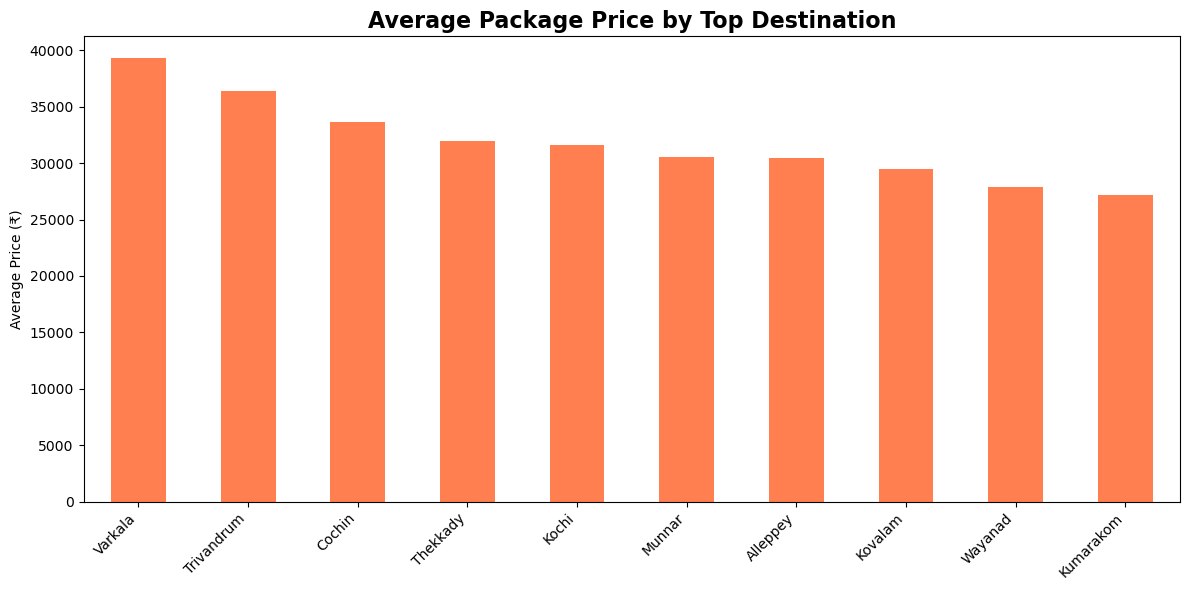

In [ ]:
# Average package price for each top destination (using 1D Cities as the anchor city)
top_cities = city_counts.head(10).index

price_by_city = {}
for city in top_cities:
    mask = df['Cities'].str.contains(city, regex=False, na=False)
    price_by_city[city] = df.loc[mask, 'New Prices'].mean()

price_by_city = pd.Series(price_by_city).sort_values(ascending=False)

plt.figure(figsize=(12,6))
price_by_city.plot(kind='bar', color='coral')
plt.title('Average Package Price by Top Destination', fontsize=16, fontweight='bold')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# **3. Price relationships**

Does a longer trip mean a proportionally higher price? Does a bigger discount apply to costlier packages? Is a higher rating associated with a higher price?

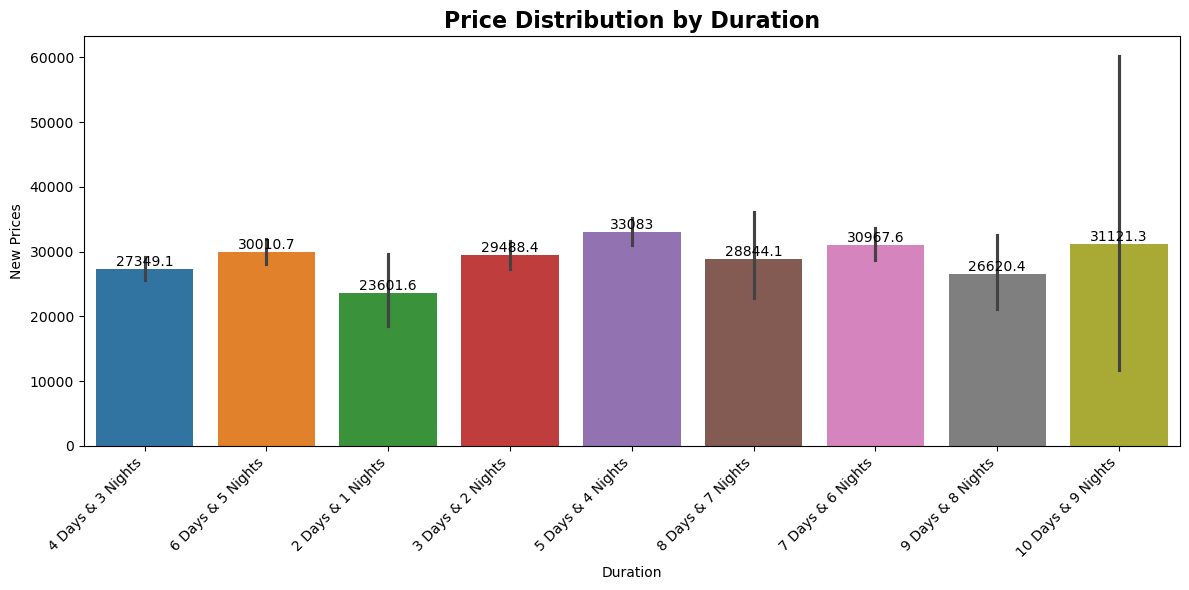

In [ ]:
# Price vs Duration
plt.figure(figsize=(12,6))
ax=sns.barplot(data=df, x='Duration', y='New Prices', palette='tab10')

for container in ax.containers:
    ax.bar_label(container)
plt.title('Price Distribution by Duration', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

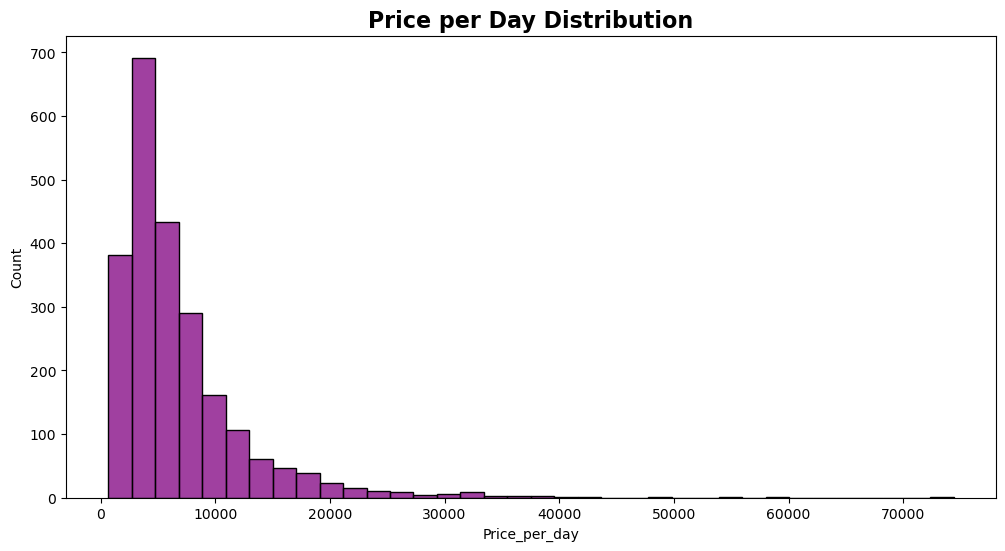

In [ ]:
# Price per day -- normalizes cost so packages of different lengths can be compared fairly
df['Price_per_day'] = df['New Prices'] / df['Days']

plt.figure(figsize=(12,6))
sns.histplot(df, x='Price_per_day', bins=36, color='purple')
plt.title('Price per Day Distribution', fontsize=16, fontweight='bold')
plt.show()


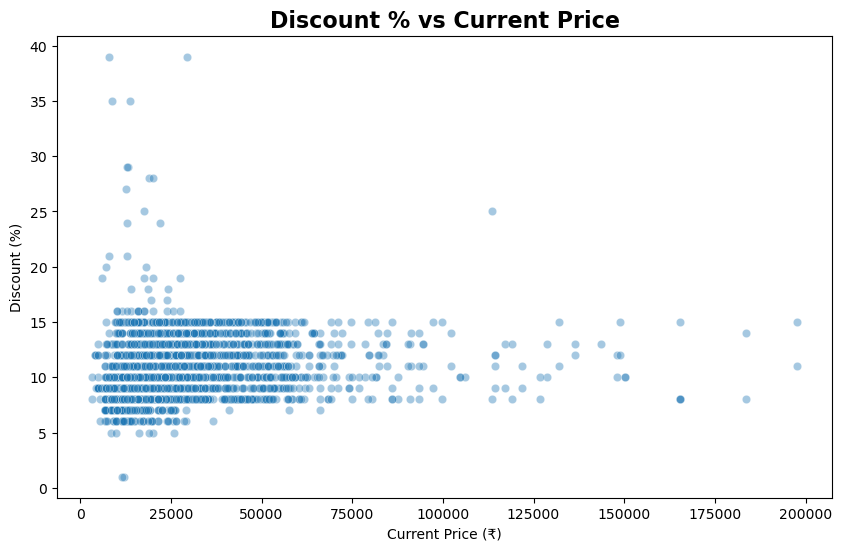

In [ ]:
# Discount % vs Price -- do pricier packages get bigger or smaller discounts?
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='New Prices', y='Discount_num', alpha=0.4)
plt.title('Discount % vs Current Price', fontsize=16, fontweight='bold')
plt.xlabel('Current Price (₹)')
plt.ylabel('Discount (%)')
plt.show()

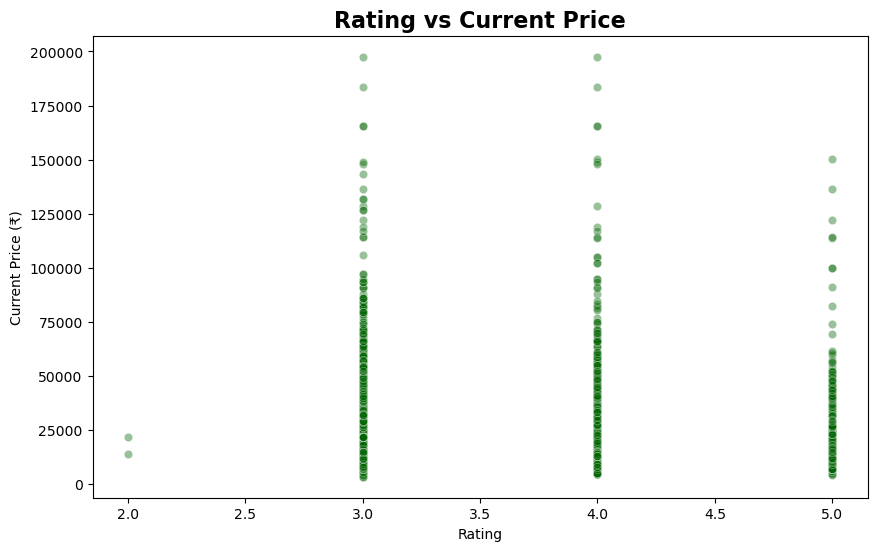

In [ ]:
# Rating vs Price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Ratings_num', y='New Prices', alpha=0.4, color='darkgreen')
plt.title('Rating vs Current Price', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Current Price (₹)')
plt.show()

# **4. Package Type comparison**

How do average price, discount, and rating differ across package types?

In [ ]:
type_summary = df.groupby('Package Type').agg(
    Avg_Price=('New Prices', 'mean'),
    Avg_Discount=('Discount_num', 'mean'),
    Avg_Rating=('Ratings_num', 'mean'),
    Count=('Package Name', 'count')
).sort_values('Avg_Price', ascending=False)

type_summary

,Avg_Price,Avg_Discount,Avg_Rating,Count
Package Type,,,,
Customizable,30007.450435,10.863043,3.522609,2300


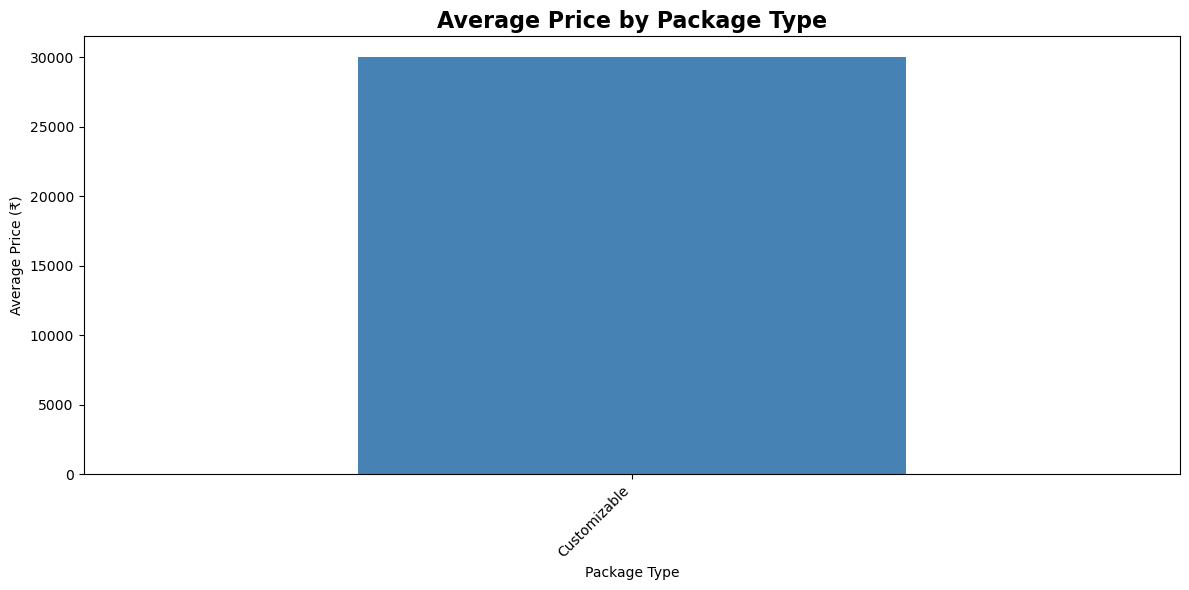

In [ ]:
plt.figure(figsize=(12,6))
type_summary['Avg_Price'].plot(kind='bar', color='steelblue')
plt.title('Average Price by Package Type', fontsize=16, fontweight='bold')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **5. Outlier detection on price**

The price histograms showed a long right tail. Flag (rather than silently drop) packages that are statistical outliers using the IQR method.

In [ ]:
Q1 = df['New Prices'].quantile(0.25)
Q3 = df['New Prices'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Price_Outlier'] = (df['New Prices'] < lower_bound) | (df['New Prices'] > upper_bound)

print(f'Lower bound: ₹{lower_bound:,.0f}, Upper bound: ₹{upper_bound:,.0f}')
print(f'Number of outlier packages: {df["Price_Outlier"].sum()} out of {len(df)}')
df[df['Price_Outlier']][['Package Name', 'New Prices', 'Duration']].sort_values('New Prices', ascending=False).head(10)


Lower bound: ₹-19,584, Upper bound: ₹72,320
Number of outlier packages: 93 out of 2300


,Package Name,New Prices,Duration
594,"6-Day Kerala Tour with Munnar, Thekkady, and A...",197580,6 Days & 5 Nights
1811,Experience the Best of Kerala with Our 5-Day Tour,197580,5 Days & 4 Nights
2178,"5-Day Kerala Tour with Munnar, Thekkady & Alle...",183696,5 Days & 4 Nights
981,5-Day Mesmeric Kerala Tour with Munnar and All...,183696,5 Days & 4 Nights
835,"7-Day Kerala Tour with Beaches, Hills & Wildlife",165440,7 Days & 6 Nights
795,4-Day Kerala Tour with Munnar and Alleppey Hou...,165440,4 Days & 3 Nights
2052,5-Day Kerala Tour Featuring Munnar and Thekkady,165440,5 Days & 4 Nights
2012,Experience the Natural Beauty of Wayanad on a ...,165440,3 Days & 2 Nights
1764,"7-Day Kerala Tour: Munnar, Alleppey, Kanyakuma...",150300,7 Days & 6 Nights
547,5-Day Kerala Tour with Houseboat Stay,150300,5 Days & 4 Nights


# **6. Best value and most expensive packages**

Concrete, scannable tables rather than just chart shapes -- directly useful for a traveler comparing options.

In [ ]:
print('Top 10 Cheapest Packages')
display(df.nsmallest(10, 'New Prices')[['Package Name', 'Duration', 'New Prices', 'Ratings', 'Discount']])

print('\nTop 10 Most Expensive Packages')
display(df.nlargest(10, 'New Prices')[['Package Name', 'Duration', 'New Prices', 'Ratings', 'Discount']])

print('\nTop 10 Best Value (lowest Price per Day, rating 4+)')
display(df[df['Ratings_num'] >= 4].nsmallest(10, 'Price_per_day')[['Package Name', 'Duration', 'New Prices', 'Price_per_day', 'Ratings']])


Top 10 Cheapest Packages


,Package Name,Duration,New Prices,Ratings,Discount
95,Kochi City Tour Package,2 Days & 1 Nights,3324,3 Star,8% Off
1292,Charismatic Kerala Family Tour,5 Days & 4 Nights,3324,3 Star,10% Off
34,Spectacular Cochin Tour Package,2 Days & 1 Nights,3973,5 Star,12% Off
1231,Book Our Alleppey Houseboat Tour Package For A...,2 Days & 1 Nights,3973,3 Star,12% Off
23,Spellbinding Cochin Family Tour Package,2 Days & 1 Nights,4480,4 Star,12% Off
1220,Exclusive Kerala Munnar Tour Packages for an A...,3 Days & 2 Nights,4480,4 Star,9% Off
25,Best Selling 2 Days Alleppey Honeymoon Package...,2 Days & 1 Nights,4799,3 Star,9% Off
27,Delightful Athirapally Tour Packages,2 Days & 1 Nights,4799,5 Star,9% Off
1222,Ecstatic Athirapally Honeymoon Package,7 Days & 6 Nights,4799,4 Star,12% Off
1224,Blissful Kerala Honeymoon Tour Package,7 Days & 6 Nights,4799,4 Star,9% Off



Top 10 Most Expensive Packages


,Package Name,Duration,New Prices,Ratings,Discount
594,"6-Day Kerala Tour with Munnar, Thekkady, and A...",6 Days & 5 Nights,197580,4 Star,11% Off
1811,Experience the Best of Kerala with Our 5-Day Tour,5 Days & 4 Nights,197580,3 Star,15% Off
981,5-Day Mesmeric Kerala Tour with Munnar and All...,5 Days & 4 Nights,183696,3 Star,14% Off
2178,"5-Day Kerala Tour with Munnar, Thekkady & Alle...",5 Days & 4 Nights,183696,4 Star,8% Off
795,4-Day Kerala Tour with Munnar and Alleppey Hou...,4 Days & 3 Nights,165440,3 Star,8% Off
835,"7-Day Kerala Tour with Beaches, Hills & Wildlife",7 Days & 6 Nights,165440,3 Star,8% Off
2012,Experience the Natural Beauty of Wayanad on a ...,3 Days & 2 Nights,165440,4 Star,8% Off
2052,5-Day Kerala Tour Featuring Munnar and Thekkady,5 Days & 4 Nights,165440,4 Star,15% Off
547,5-Day Kerala Tour with Houseboat Stay,5 Days & 4 Nights,150300,5 Star,10% Off
1764,"7-Day Kerala Tour: Munnar, Alleppey, Kanyakuma...",7 Days & 6 Nights,150300,4 Star,10% Off



Top 10 Best Value (lowest Price per Day, rating 4+)


,Package Name,Duration,New Prices,Price_per_day,Ratings
1222,Ecstatic Athirapally Honeymoon Package,7 Days & 6 Nights,4799,685.571429,4 Star
1224,Blissful Kerala Honeymoon Tour Package,7 Days & 6 Nights,4799,685.571429,4 Star
2026,"7-Day Kerala Tour with Munnar, Thekkady & Alle...",7 Days & 6 Nights,5000,714.285714,4 Star
1387,Alluring Kumarakom Tour Package,7 Days & 6 Nights,5865,837.857143,5 Star
2292,"5-Day Kerala Tour Package with Munnar, Thekkad...",5 Days & 4 Nights,5000,1000.000000,4 Star
2299,"7-Day Kerala Tour with Munnar, Thekkady & Back...",7 Days & 6 Nights,8000,1142.857143,4 Star
724,Best Kerala Tour Package From Kolkata For A Me...,6 Days & 5 Nights,6999,1166.500000,4 Star
1201,Charismatic Kochi Tour Package,4 Days & 3 Nights,4800,1200.000000,4 Star
1169,"8-Day Kerala Package: Romance, Wildlife, and S...",8 Days & 7 Nights,9601,1200.125000,4 Star
809,4-Day Kerala Escape with Houseboat Experience,4 Days & 3 Nights,5000,1250.000000,4 Star


# **7. Correlation with cleaned numeric features**

Revisit the correlation heatmap now that Duration, Discount, and Ratings are proper numbers instead of strings/categories.

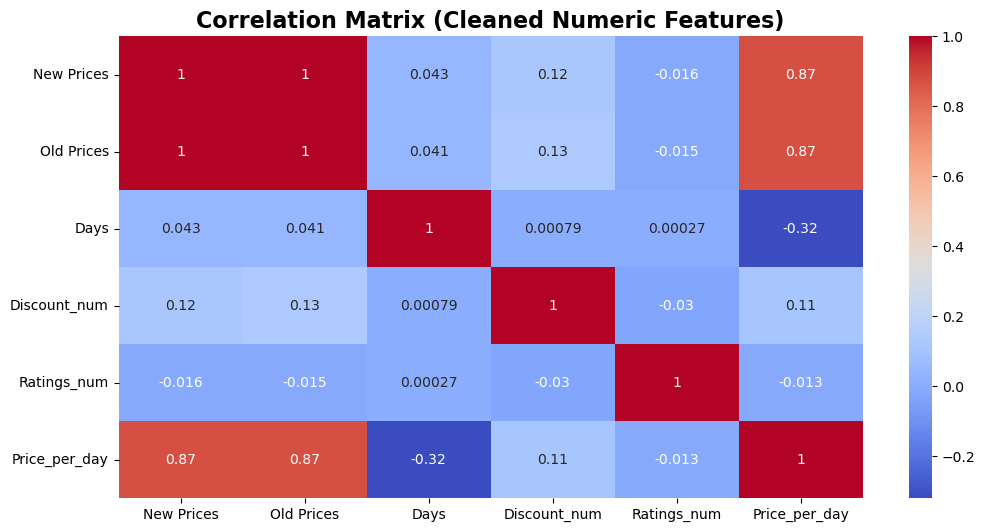

In [ ]:
plt.figure(figsize=(12,6))
num_cols = ['New Prices', 'Old Prices', 'Days', 'Discount_num', 'Ratings_num', 'Price_per_day']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Cleaned Numeric Features)', fontsize=16, fontweight='bold')
plt.show()

# **Possible Outcomes:**

The dataset include 2,400 Kerala tour packages scraped from TravelTriangle, with columns for package name, type, duration, ratings, discount, current price, original price, and a destinations string later split into 1/2/3-day city stops.

Pricing insights. Both price distributions show mean current prices around ₹29,773 with a standard deviation of about ₹22,667, and mean original prices around ₹33,534 with a standard deviation near ₹25,620. Both histograms are right-skewed: most packages sit in the ₹10,000–40,000 band, with a long thin tail running out past ₹150,000 for luxury packages. The median package costs about ₹23,900 currently versus ₹26,985 originally, so the typical discount knocks several thousand rupees off.

Duration patterns. 5 Days & 4 Nights is the most common package (631 of 2,400), followed by 4 Days & 3 Nights (574) and 3 Days & 2 Nights (423). Longer trips (8+ days) are rare, suggesting TravelTriangle's Kerala catalog is weighted toward short weekend/midweek getaways rather than extended tours.

Hotel category split. The ratings pie shows 3-star packages dominate at 56.29%, 4-star sit at 33.92%, 5-star a modest 9.58%, and 2-star almost nonexistent at 0.21%. So this catalog skews budget-to-midrange rather than luxury.
Discount patterns. Discounts cluster heavily around two values: 9% off (414 packages) and 8% off (369 packages), with 10%, 11%, 12%, and 13% also common. Very large discounts (25%+) are rare outliers. This tells a traveler that "look for a deal" mostly means expecting single-digit-to-low-teens savings, not dramatic markdowns.